In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent  # parent of notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from src.visualization.plot_vertical_profile import (
    plot_vertical_profile_at_timestamp,
    plot_time_averaged_vertical_profile,
    plot_vertical_profile_heatmap,
)

In [4]:
ARTIFACTS = Path("../artifacts")
DATA_PATH = ARTIFACTS / "previousDesign_merged.parquet"
SPEC_PATH = ARTIFACTS / "feature_target_spec.json"

# Load merged dataset (Parquet is best for training/read performance)
df = pd.read_parquet(DATA_PATH)

In [5]:


# If your index is not timestamp, try:
# df = pd.read_parquet(DATA_PATH)
# df["timestamp"] = pd.to_datetime(df["timestamp"])
# df = df.set_index("timestamp")

spec = json.loads(Path(SPEC_PATH).read_text())
feature_cols = spec["feature_cols"]
target_cols = spec["target_cols_raw"]

print("Features:", feature_cols)
print("Targets:", target_cols[:5], "... total:", len(target_cols))

Features: ['airflow_lps', 'cool_output_kwh', 'cool_demand_kwh', 'evap_fan_speed_pct', 'return_air_c', 'suction_c', 'supply_air_c', 'min_rack_inlet_c']
Targets: ['temp_cabin3_back_34u_c', 'temp_cabin3_back_24u_c', 'temp_cabin3_back_22u_c', 'temp_cabin3_back_20u_c', 'temp_cabin3_back_28u_c'] ... total: 12


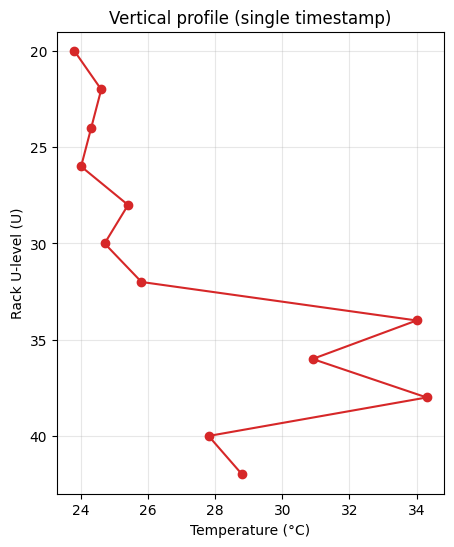

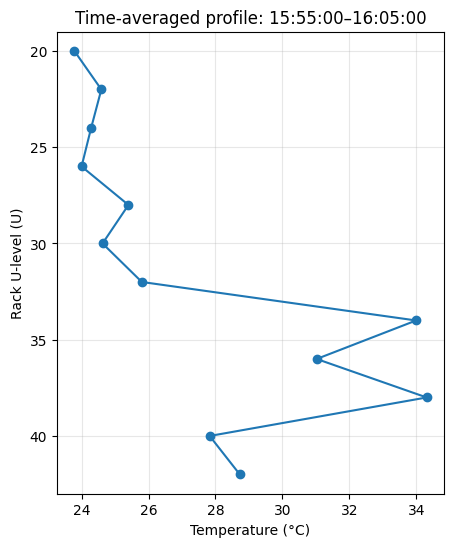

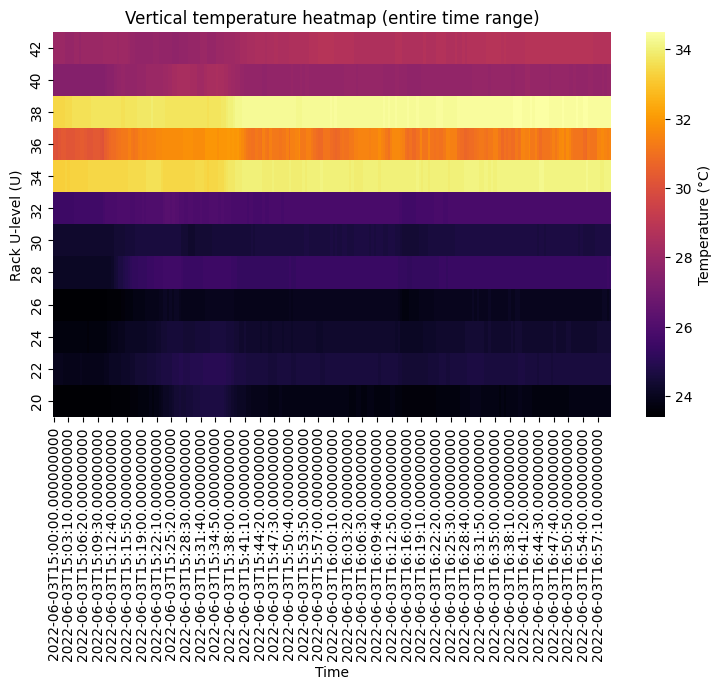

In [6]:
# Pick a timestamp present in the index
ts = df.index[int(len(df) * 0.5)]  # midpoint timestamp

# 1) Single timestamp vertical profile
_ = plot_vertical_profile_at_timestamp(df, timestamp=ts, cabin_filter="cabin3",
                                       title="Vertical profile (single timestamp)")
plt.show()

# 2) Time-averaged vertical profile over a 10-minute window around ts
start = ts - pd.Timedelta("5min")
end   = ts + pd.Timedelta("5min")
_ = plot_time_averaged_vertical_profile(df, start=start, end=end, cabin_filter="cabin3",
                                        title=f"Time-averaged profile: {start:%H:%M:%S}–{end:%H:%M:%S}")
plt.show()

# 3) Heatmap across the full time range (this is excellent for hotspot diagnosis)
_ = plot_vertical_profile_heatmap(df, cabin_filter="cabin3",
                                  title="Vertical temperature heatmap (entire time range)")
plt.show()